In [14]:
# ============================================================================
# 📚 SECTION 0: IMPORT LIBRARIES & CLEARML SETUP
# ============================================================================

# ==========================================
# 📦 CORE LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 🤖 MACHINE LEARNING LIBRARIES
# ==========================================
# Sklearn - Models
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    ExtraTreesRegressor,
    AdaBoostRegressor,
    BaggingRegressor
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    HuberRegressor,
    BayesianRidge
)

# Sklearn - Preprocessing & Metrics
from sklearn.base import clone
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Hyperparameter Optimization
import optuna
from optuna.samplers import TPESampler

# Model Persistence
import joblib
import os
import sys
import time
from datetime import timedelta

# ==========================================
# 🔧 CLEARML SETUP
# ==========================================
print(f"🐍 Python executable: {sys.executable}\n")

# Set ClearML credentials
os.environ['CLEARML_WEB_HOST'] = 'https://app.clear.ml'
os.environ['CLEARML_API_HOST'] = 'https://api.clear.ml'
os.environ['CLEARML_FILES_HOST'] = 'https://files.clear.ml'
os.environ['CLEARML_API_ACCESS_KEY'] = 'J5WRKN4TPMIZNR6UFE18HHVQISCLIE'
os.environ['CLEARML_API_SECRET_KEY'] = 'CDFJ26MFOfmqnfSxEOfRnawhIVnqutqe7g3_pw5Z-YmCXwNmcq_O0Ok9KPKnIYUvZ9E'

# Import ClearML
try:
    from clearml import Task, Logger
    CLEARML_AVAILABLE = True
    print("✅ ClearML imported successfully!")
    print("📊 Visit https://app.clear.ml to view your experiments\n")
except ImportError:
    CLEARML_AVAILABLE = False
    print("⚠️  ClearML not installed. Install with: pip install clearml")
    print("   Continuing without experiment tracking...\n")

# Initialize ClearML Task
task = None
logger = None

if CLEARML_AVAILABLE:
    try:
        task = Task.init(
            project_name='Temperature_Prediction_Hanoi',
            task_name='Feature_Engineering_Complete_Pipeline_v2',
            tags=['feature-engineering', 'temperature', 'time-series', 'hanoi', 'optuna'],
            reuse_last_task_id=False
        )
        logger = task.get_logger()
        
        print("✅ ClearML Task initialized successfully!")
        print(f"📊 Project: Temperature_Prediction_Hanoi")
        print(f"🏷️  Task: Feature_Engineering_Complete_Pipeline_v2")
        print(f"🌐 View dashboard: https://app.clear.ml\n")
        
    except Exception as e:
        print(f"⚠️  ClearML configuration error: {str(e)}")
        print("   Continuing without experiment tracking...\n")
        task = None
        logger = None
        CLEARML_AVAILABLE = False

print("="*80)
print("✅ ALL LIBRARIES LOADED SUCCESSFULLY")
print("="*80)

🐍 Python executable: /Library/Developer/CommandLineTools/usr/bin/python3

✅ ClearML imported successfully!
📊 Visit https://app.clear.ml to view your experiments

✅ ClearML Task initialized successfully!
📊 Project: Temperature_Prediction_Hanoi
🏷️  Task: Feature_Engineering_Complete_Pipeline_v2
🌐 View dashboard: https://app.clear.ml

✅ ALL LIBRARIES LOADED SUCCESSFULLY


In [15]:
import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


# HOURLY DATA

In [ ]:


print("\n" + "="*80)
print("📂 LOADING HOURLY DATA")
print("="*80)

read_dir = '../data/processed/'
train_data_h = pd.read_excel(read_dir + 'train_data_h.xlsx')
val_data_h = pd.read_excel(read_dir + 'val_data_h.xlsx')
test_data_h = pd.read_excel(read_dir + 'test_data_h.xlsx')
X_train_h = pd.read_excel(read_dir + 'X_train_h.xlsx')
y_train_h = pd.read_excel(read_dir + 'y_train_h.xlsx')
X_val_h = pd.read_excel(read_dir + 'X_val_h.xlsx')
y_val_h = pd.read_excel(read_dir + 'y_val_h.xlsx')
X_test_h = pd.read_excel(read_dir + 'X_test_h.xlsx')
y_test_h = pd.read_excel(read_dir + 'y_test_h.xlsx')

print(f"✅ Train data shape: {train_data_h.shape}")
print(f"✅ Validation data shape: {val_data_h.shape}")
print(f"✅ Test data shape: {test_data_h.shape}")


📂 LOADING HOURLY DATA
✅ Train data shape: (67968, 53)
✅ Validation data shape: (10944, 53)
✅ Test data shape: (15336, 53)


In [17]:
def create_hourly_features_and_split(df):
    df = df.copy()
    
    # ======================
    # Basic differences & heatwave
    # ======================
    if 'temp' in df.columns and 'feelslike' in df.columns and 'dew' in df.columns:
        df['temp_dew_diff'] = df['temp'] - df['dew']
        df['feelslike_diff'] = df['feelslike'] - df['temp']
    
    # ======================
    # Wind components
    # ======================
    if 'windspeed' in df.columns and 'winddir' in df.columns:
        df['wind_U'] = df['windspeed'] * np.sin(2*np.pi*df['winddir']/360)
        df['wind_V'] = df['windspeed'] * np.cos(2*np.pi*df['winddir']/360)
    
    # ======================
    # Pressure change
    # ======================
    if 'sealevelpressure' in df.columns:
        df['pressure_hourly_change'] = df['sealevelpressure'].diff(1)
    
    # ======================
    # Solar-cloud interaction
    # ======================
    if 'solarradiation' in df.columns and 'cloudcover' in df.columns:
        df['solar_cloud_interaction'] = df['solarradiation'] * (1 - df['cloudcover']/100)
    
    # ======================
    # Cyclical time features
    # ======================
    if 'datetime' in df.columns:
        df['month_sin'] = np.sin(2*np.pi*df['datetime'].dt.month/12)
        df['month_cos'] = np.cos(2*np.pi*df['datetime'].dt.month/12)
        df['day_sin'] = np.sin(2*np.pi*df['datetime'].dt.day_of_year/365.25)
        df['day_cos'] = np.cos(2*np.pi*df['datetime'].dt.day_of_year/365.25)
        df['hour_sin'] = np.sin(2*np.pi*df['datetime'].dt.hour/24)
        df['hour_cos'] = np.cos(2*np.pi*df['datetime'].dt.hour/24)
    
    # ======================
    # Rolling features 
    # ======================
    roll_cols = ['temp','feelslike','dew','humidity','precip','precipprob','windgust','windspeed',
                 'sealevelpressure','cloudcover','solarradiation','solarenergy','solar_cloud_interaction',
                 'wind_U','wind_V']
    windows = [3, 6, 12, 24] 
    roll_features = []
    for col in roll_cols:
        if col not in df.columns: continue
        col_upper = col.upper()
        for w in windows:
            roll_features.append(df[col].shift(1).rolling(window=w, min_periods=1).mean().rename(f"{w}H_AVG_{col_upper}"))
            roll_features.append(df[col].shift(1).rolling(window=w, min_periods=1).var().rename(f"{w}H_VAR_{col_upper}"))
    
    # ======================
    # Static / direct features
    # ======================
    direct_cols = ['temp','feelslike','dew','humidity','precip','precipprob','windgust','windspeed',
                   'sealevelpressure','cloudcover','solarradiation','solarenergy','solar_cloud_interaction',
                   'wind_U','wind_V','hour_sin','hour_cos','month_sin','month_cos','day_sin','day_cos']
    direct_features = [df[c] for c in direct_cols if c in df.columns]
    
    # ======================
    # Combine features
    # ======================
    features_df = pd.concat(roll_features + direct_features, axis=1)
    
    # ======================
    # Targets: 1h, 2h, 3h later
    # ======================
    target_data = {}
    for h in range(1,4):
        target_data[f'y_temp_h_{h}'] = df['temp'].shift(-h)
    y = pd.DataFrame(target_data, index=df.index)
    
    # ======================
    # Final dataset
    # ======================
    full_df = pd.concat([features_df, y], axis=1).dropna()
    X = full_df.drop(columns=target_data.keys())
    y = full_df[list(target_data.keys())]
    
    return X, y


In [18]:
X_train_h, y_train_h = create_hourly_features_and_split(train_data_h)
X_val_h, y_val_h = create_hourly_features_and_split(val_data_h)
X_test_h, y_test_h = create_hourly_features_and_split(test_data_h)

## **SECTION 2:** 📊 SCALER TESTING & COMPARISON

After testing different scaling methods on the daily dataset, we observed that **SafeMinMaxScaler [0,1] and [-1,1] consistently provided the best performance** for linear models in terms of stability and error reduction. 

**Conclusion & Recommendation:**
- Apply **SafeMinMaxScaler [0,1] and [-1,1]** to hourly data as well to ensure consistent scaling across features.
- All scalers are fit **only on training data** to avoid data leakage, and validation/test sets are transformed using the training statistics.


### Feature Scaling Strategy (Hourly Data)

To avoid **data leakage** and ensure honest evaluation for our hourly temperature forecasting:

- We first **split the data** into `Train_h`, `Validation_h (Val_h)`, and `Test_h`.
- All scalers that rely on statistics (e.g., min, max) are **fit only on `X_train_h`**.
- We then **transform `X_train_h` and `X_val_h`** with these scalers.
- During this phase, **`X_test_h` is untouched**—it is neither transformed nor used.
- Scalers such as SigmoidScaler or TanhScaler **do not require fitting**, which further minimizes leakage risk.

After selecting the **best scaler** based on validation performance, we **refit that scaler on the combined (Train_h + Val_h)** set and then transform the **Test_h** set for final evaluation. This guarantees that the Test set remains a true hold-out.

---

#### 3.2.1. Overview of Scaling Methods

| Scaler name (in code)         | Class / Type              | Core transformation formula                                                                 | Uses data statistics?          | Data used when fitting during comparison | Data transformed during comparison        | Leakage risk explanation                                                                 |
|-------------------------------|---------------------------|---------------------------------------------------------------------------------------------|---------------------------------|-------------------------------------------|-------------------------------------------|------------------------------------------------------------------------------------------|
| `MinMax_[0,1]_SAFE`           | `SafeMinMaxScaler`        | \( x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}} \) then rescaled to \([0, 1]\)            | ✅ Yes – from **X_train_h only** | Fit on `X_train_h`                        | Transform `X_train_h`, `X_val_h`          | No leakage: statistics computed on training set only; Val/Test untouched.               |
| `MinMax_[-1,1]_SAFE`          | `SafeMinMaxScaler`        | Same as above but scaled to \([-1, 1]\)                                                     | ✅ Yes – from **X_train_h only** | Fit on `X_train_h`                        | Transform `X_train_h`, `X_val_h`          | Same as above.                                                                           |
---

#### 3.2.2. Detailed No-Leakage Procedure (Hourly Pipeline)

1. **Split data first**  

   - Disjoint sets:
     - `Train_h` – used to compute scaler statistics and train models.
     - `Validation_h` – used for scaler and model selection.
     - `Test_h` – strictly reserved for final evaluation.

2. **Scaling during model/scaler comparison**

   - For Safe MinMax scaler:
     - `scaler.fit(X_train_h)` → stores min/max of `X_train_h`.
     - Transform:
       - `X_train_scaled = scaler.transform(X_train_h)`
       - `X_val_scaled   = scaler.transform(X_val_h)`
   - **Do not touch `X_test_h`** at this stage.
   - Validation metrics (MAE, \(R^2\), overfitting gaps) are computed only on scaled `Train_h` and `Val_h`.

3. **Cleaning feature names**

   - Call `clean_feature_names(df)` on all datasets to:
     - Remove special characters like `[ ] < > : ,` and spaces.
     - Collapse multiple underscores and trim edges.
   - Does **not** affect values or statistics—hence, no leakage.

4. **Final Test set scaling and evaluation**

   - After selecting the best scaler (MinMaxScaler in our experiments):
     - Refit scaler on combined `(Train_h + Val_h)` raw features.
     - Transform `(Train_h + Val_h)` and `Test_h`.
     - Train final model on scaled `(Train_h + Val_h)` and evaluate on scaled `Test_h`.

   - Guarantees:
     - Test set remains a **true hold-out**.
     - No influence on scaler or model selection.

---

#### 3.2.3. Why This Matters for Hourly Models

- Models sensitive to feature scale:
  - Linear models: LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, Huber.
  - Distance-based: KNN with RBF kernel.
  - Gradient-based / regularized: MLP.
- Proper scaling ensures:
  - Faster convergence.
  - Stable training.
  - Accurate assessment of generalization.
- By:
  - fitting scalers **only on Train_h**,
  - selecting based on **Val_h** metrics,
  - reserving `Test_h` for final evaluation,
- we maintain **honest, no-leakage performance reporting** for our hourly temperature forecasting pipeline.

---

In [19]:
# ========================================== 
# 📊 PREPARE DATA WITH SCALING (NO LEAKAGE - SAFE VERSION, NO TEST USED HERE)
# ==========================================

# Models that NEED scaling
models_need_scaling = [
    'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN', 'MLP', 'Huber', 'Bayesian Ridge'
]

print("🧪 TESTING SAFE SCALING METHODS (100% NO DATA LEAKAGE ON TEST)\n")
print("="*80)

# ==========================================
# 🎯 DEFINE SAFE SCALING FUNCTIONS
# ==========================================

class SafeMinMaxScaler:
    """
    MinMaxScaler is safe - only learns from the train set
    Formula: X_scaled = (X - min) / (max - min)
    """
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
        self.min_ = None
        self.max_ = None
        self.data_min_ = None
        self.data_max_ = None
        
    def fit(self, X):
        """Only learn min/max from TRAIN SET"""
        self.data_min_ = X.min(axis=0)
        self.data_max_ = X.max(axis=0)
        self.min_, self.max_ = self.feature_range
        return self
    
    def transform(self, X):
        """Transform based on min/max learned from train"""
        X_std = (X - self.data_min_) / (self.data_max_ - self.data_min_ + 1e-8)
        X_scaled = X_std * (self.max_ - self.min_) + self.min_
        return X_scaled
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

# ==========================================
# 🔬 TEST ALL SCALING METHODS (ONLY TRAIN + VAL)
# ==========================================

scalers_config = {
    'MinMax_[0,1]_SAFE': SafeMinMaxScaler(feature_range=(0, 1))
}

# Dictionary to store scaled datasets (only train + val)
scaled_datasets = {}

for scaler_name, scaler in scalers_config.items():
    print(f"\n{'─'*80}")
    print(f"🔧 Scaling with: {scaler_name}")
    print(f"{'─'*80}")
    
    try:
        scaler.fit(X_train_h)
        
        # Transform TRAIN + VAL
        X_train_scaled = scaler.transform(X_train_h)
        X_val_scaled   = scaler.transform(X_val_h)
        
        # Convert to DataFrame
        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_h.columns, index=X_train_h.index)
        X_val_scaled_df   = pd.DataFrame(X_val_scaled,   columns=X_val_h.columns,   index=X_val_h.index)
        
        # Store results
        scaled_datasets[scaler_name] = {
            'X_train_h': X_train_scaled_df,
            'X_val_h': X_val_scaled_df,
            'scaler': scaler
        }
        
        # Show statistics (only train/val)
        print(f"   ✅ Scaling successful")
        print(f"   📊 Train range (first feature): [{X_train_scaled_df.iloc[:, 0].min():.4f}, {X_train_scaled_df.iloc[:, 0].max():.4f}]")
        print(f"   📊 Val range   (first feature): [{X_val_scaled_df.iloc[:, 0].min():.4f}, {X_val_scaled_df.iloc[:, 0].max():.4f}]")
        
        if 'Sigmoid' in scaler_name or 'Tanh' in scaler_name:
            print(f"   ✅ NO LEAKAGE - Method doesn't use training statistics")
        
    except Exception as e:
        print(f"   ❌ ERROR: {str(e)}")

print("\n" + "="*80)
print(f"✅ Created {len(scaled_datasets)} scaled versions (TRAIN + VAL ONLY, TEST UNTOUCHED)")
print("="*80)

# ==========================================
# 🧹 CLEAN FEATURE NAMES
# ==========================================

def clean_feature_names(df):
    special_chars = ['[', ']', '<', '>', ':', ',', ' ']
    new_columns = {}
    for col in df.columns:
        new_col = col
        for char in special_chars:
            new_col = new_col.replace(char, '_')
        while '__' in new_col:
            new_col = new_col.replace('__', '_')
        new_col = new_col.strip('_')
        new_columns[col] = new_col
    return df.rename(columns=new_columns)

# Clean original data (train, val, test)
X_train_h = clean_feature_names(X_train_h)
X_val_h   = clean_feature_names(X_val_h)
X_test_h  = clean_feature_names(X_test_h)

# Clean scaled versions (train + val)
for scaler_name in scaled_datasets.keys():
    scaled_datasets[scaler_name]['X_train_h'] = clean_feature_names(scaled_datasets[scaler_name]['X_train_h'])
    scaled_datasets[scaler_name]['X_val_h']   = clean_feature_names(scaled_datasets[scaler_name]['X_val_h'])

print("✅ Feature names cleaned for train/val and raw test (no test used in scaler comparison)")


🧪 TESTING SAFE SCALING METHODS (100% NO DATA LEAKAGE ON TEST)


────────────────────────────────────────────────────────────────────────────────
🔧 Scaling with: MinMax_[0,1]_SAFE
────────────────────────────────────────────────────────────────────────────────
   ✅ Scaling successful
   📊 Train range (first feature): [0.0000, 1.0000]
   📊 Val range   (first feature): [0.0720, 0.9431]

✅ Created 1 scaled versions (TRAIN + VAL ONLY, TEST UNTOUCHED)
✅ Feature names cleaned for train/val and raw test (no test used in scaler comparison)


In [20]:
# ==========================================
# 🔬 SELECT BEST SCALER – ONLY MinMax_[0,1]_SAFE
# ==========================================

def select_best_scaler_minmax_log(
    models_dict,
    scaled_dataset,
    X_train_h_raw, X_val_h_raw,
    y_train_h, y_val_h,
    target_col
):
    """
    - Use MinMax_[0,1]_SAFE only
    - Fit on TRAIN (150 selected features)
    - Eval on VAL (auto-reindex by train features)
    - Refit scaler on TRAIN+VAL raw
    - Print compact logs in Markdown style
    """
    scaler_name = list(scaled_dataset.keys())[0]
    data = scaled_dataset[scaler_name]
    X_tr = data['X_train_h']
    X_vl = data['X_val_h']
    scaler = data['scaler']
    
    # Sync columns val theo train (only choose features used in train)
    X_vl = X_vl.reindex(columns=X_tr.columns, fill_value=0)
    
    all_rows = []

    print("🧪 TESTING SAFE SCALING METHODS (100% NO DATA LEAKAGE)")
    print("="*80)
    print(f"\n────────────────────────────────────────────────────────────────────────────────")
    print(f"🔧 Scaling with: {scaler_name}")
    print(f"────────────────────────────────────────────────────────────────────────────────")
    
    for model_name, model_instance in models_dict.items():
        try:
            model = clone(model_instance)
            start_time = time.time()
            model.fit(X_tr, y_train_h[target_col])
            train_time = time.time() - start_time
            
            y_val_pred = model.predict(X_vl)
            mae_val = mean_absolute_error(y_val_h[target_col], y_val_pred)
            r2_val = r2_score(y_val_h[target_col], y_val_pred)
            
            all_rows.append({
                'Model': model_name,
                'Val_MAE': mae_val,
                'Val_R²': r2_val
            })
            
            print(f"   🔹 {model_name}: Val MAE={mae_val:.4f} | Val R²={r2_val:.4f}")
        except Exception as e:
            print(f"   ❌ {model_name} ERROR: {str(e)}")
    
    results_df = pd.DataFrame(all_rows)
    
    # Refit scaler trên TRAIN+VAL raw (only selected features)
    X_tr_full_raw = pd.concat([X_train_h_raw[X_tr.columns], X_val_h_raw[X_tr.columns]])
    y_tr_full     = pd.concat([y_train_h, y_val_h])
    scaler.fit(X_tr_full_raw)
    
    X_tr_full_scaled = pd.DataFrame(
        scaler.transform(X_tr_full_raw),
        columns=X_tr_full_raw.columns,
        index=X_tr_full_raw.index
    )
    
    return scaler_name, results_df, scaler, X_tr_full_scaled, y_tr_full


In [21]:
models_dict = {
    "LinearRegression": LinearRegression(n_jobs=-1),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000),
    "Huber": HuberRegressor(epsilon=1.35, max_iter=200),
    "BayesianRidge": BayesianRidge(compute_score=False),
}

scaler_name, results_df, scaler, X_tr_full_scaled, y_tr_full = select_best_scaler_minmax_log(
    models_dict=models_dict,
    scaled_dataset=scaled_datasets,
    X_train_h_raw=X_train_h,
    X_val_h_raw=X_val_h,
    y_train_h=y_train_h,
    y_val_h=y_val_h,
    target_col='y_temp_h_1'
)


🧪 TESTING SAFE SCALING METHODS (100% NO DATA LEAKAGE)

────────────────────────────────────────────────────────────────────────────────
🔧 Scaling with: MinMax_[0,1]_SAFE
────────────────────────────────────────────────────────────────────────────────
   🔹 LinearRegression: Val MAE=0.5615 | Val R²=0.9796
   🔹 Ridge: Val MAE=0.5641 | Val R²=0.9794
   🔹 Lasso: Val MAE=0.5757 | Val R²=0.9786
   🔹 ElasticNet: Val MAE=0.6076 | Val R²=0.9766
   🔹 Huber: Val MAE=0.5705 | Val R²=0.9789
   🔹 BayesianRidge: Val MAE=0.5614 | Val R²=0.9796


In [22]:
# ==========================================
# 🔧 TRANSFORM TEST SET WITH MINMAXSCALER
# ==========================================

print(f"\n{'='*80}")
print(f"🔧 TRANSFORMING TEST SET WITH MINMAXSCALER")
print(f"{'='*80}")

scaler_name = scaled_datasets['MinMax_[0,1]_SAFE']['scaler']

# Transform test set using MinMaxScaler (already fitted on train+val)
X_test_scaled = scaler_name.transform(X_test_h)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test_h.columns,
    index=X_test_h.index
)
X_test_scaled_df = clean_feature_names(X_test_scaled_df)

# Also prepare scaled train and val for models that need scaling
X_train_scaled_df = scaled_datasets['MinMax_[0,1]_SAFE']['X_train_h']
X_val_scaled_df = scaled_datasets['MinMax_[0,1]_SAFE']['X_val_h']

print(f"\n✅ Test set transformation completed!")
print(f"📊 X_train_scaled shape: {X_train_scaled_df.shape}")
print(f"📊 X_val_scaled shape: {X_val_scaled_df.shape}")
print(f"📊 X_test_scaled shape: {X_test_scaled_df.shape}")
print(f"📊 Test set range (first feature): [{X_test_scaled_df.iloc[:, 0].min():.4f}, {X_test_scaled_df.iloc[:, 0].max():.4f}]")

print(f"\n{'='*80}")
print(f"✅ ALL SCALED DATASETS READY FOR MODEL TRAINING")
print(f"{'='*80}\n")



🔧 TRANSFORMING TEST SET WITH MINMAXSCALER

✅ Test set transformation completed!
📊 X_train_scaled shape: (67963, 141)
📊 X_val_scaled shape: (10939, 141)
📊 X_test_scaled shape: (15331, 141)
📊 Test set range (first feature): [0.0588, 0.9526]

✅ ALL SCALED DATASETS READY FOR MODEL TRAINING



## **SECTION 3:** 🎯 MODEL COMPARISON

Train and compare specific models with detailed metrics for all 3 prediction hours.

**Selected Models:**
- 🌲 Random Forest – Ensemble model, based on decision trees
- 🌳 Extra Trees – Ensemble, tree-based, increased randomness
- 💡 LightGBM – Gradient Boosting, optimizes speed and performance
- 🚀 XGBoost – Gradient Boosting, powerful for big data
- 📊 Bayesian Ridge – Linear, probabilistic, probability estimation
- 📉 Ridge Regression – Linear with L2 regularization

**Output Format:**
- MAE, RMSE, R² metrics on Train / Validation / Test set
- Overfitting analysis (gap Train ↔ Test / Validation)
- Performance degradation analysis over forecasting time (Hour 1 → Hour 3)

In [23]:
# ==========================================
# 🧹 ENHANCED FEATURE NAME CLEANING FOR LIGHTGBM
# ==========================================

def clean_feature_names_lightgbm(df):
    """
    LightGBM-safe feature name cleaning
    Removes ALL special characters that LightGBM doesn't accept
    """
    import re
    
    new_columns = {}
    for col in df.columns:
        # Replace all non-alphanumeric characters with underscore
        new_col = re.sub(r'[^a-zA-Z0-9_]', '_', str(col))
        
        # Remove multiple consecutive underscores
        new_col = re.sub(r'_+', '_', new_col)
        
        # Remove leading/trailing underscores
        new_col = new_col.strip('_')
        
        # Ensure column name is not empty
        if not new_col:
            new_col = f'feature_{df.columns.get_loc(col)}'
        
        new_columns[col] = new_col
    
    return df.rename(columns=new_columns)

# ==========================================
# 🔧 APPLY CLEANING TO ALL DATASETS
# ==========================================

print("\n" + "="*80)
print("🧹 CLEANING FEATURE NAMES FOR LIGHTGBM COMPATIBILITY")
print("="*80)

# Clean original datasets
X_train = clean_feature_names_lightgbm(X_train_h)
X_val = clean_feature_names_lightgbm(X_val_h)
X_test = clean_feature_names_lightgbm(X_test_h)

# Clean scaled datasets
X_train_scaled_df = clean_feature_names_lightgbm(X_train_scaled_df)
X_val_scaled_df = clean_feature_names_lightgbm(X_val_scaled_df)
X_test_scaled_df = clean_feature_names_lightgbm(X_test_scaled_df)

# Also update in scaled_datasets dictionary
for scaler_name in scaled_datasets.keys():
    scaled_datasets[scaler_name]['X_train_h'] = clean_feature_names_lightgbm(
        scaled_datasets[scaler_name]['X_train_h']
    )
    scaled_datasets[scaler_name]['X_val_h'] = clean_feature_names_lightgbm(
        scaled_datasets[scaler_name]['X_val_h']
    )

print("✅ All feature names cleaned successfully!")
print(f"📊 Sample cleaned column names:")
print(f"   {list(X_train_h.columns[:5])}")
print("="*80 + "\n")


🧹 CLEANING FEATURE NAMES FOR LIGHTGBM COMPATIBILITY
✅ All feature names cleaned successfully!
📊 Sample cleaned column names:
   ['3H_AVG_TEMP', '3H_VAR_TEMP', '6H_AVG_TEMP', '6H_VAR_TEMP', '12H_AVG_TEMP']



In [32]:
# ==========================================
# 🎯 DIRECTED MODEL
# ==========================================

def adjusted_r2_score(y_true, y_pred, n_features):
    """Calculate Adjusted R² Score"""
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return adj_r2

# ==========================================
# 📊 DEFINE MODELS TO COMPARE
# ==========================================

models_to_compare = {
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=150,
            max_depth=5,
            # min_samples_leaf=10,
            # min_samples_split=20,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ),
        'needs_scaling': False
    },
    'Extra Trees': {
        'model': ExtraTreesRegressor(
            n_estimators=150,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ),
        'needs_scaling': False
    },
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        'needs_scaling': False
    },
    'LightGBM': {
        'model': LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'needs_scaling': False
    },
    'CatBoost': {  
        'model': CatBoostRegressor(
            depth=6,
            learning_rate=0.1,
            n_estimators=300,
            loss_function='RMSE',
            random_seed=42,
            verbose=False
        ),
        'needs_scaling': False  
    },
    'Ridge': {
        'model': Ridge(alpha=1.0, random_state=42),
        'needs_scaling': True
    },
    'Bayesian Ridge': {
        'model': BayesianRidge(compute_score=True),
        'needs_scaling': True
    }
}

# ==========================================
# 📊 TRAINING CONFIGURATION
# ==========================================

target_cols = list(y_train_h.columns)  # ['y_temp_h_1', 'y_temp_h_2','y_temp_h_3']
n_features = X_train_h.shape[1]

print(f"{'='*100}")
print(f"🎯 DETAILED MODEL COMPARISON - 3-HOUR TEMPERATURE PREDICTION")
print(f"{'='*100}")
print(f"📊 Number of features: {n_features}")
print(f"📊 Train samples: {len(X_train_h)} | Val samples: {len(X_val_h)} | Test samples: {len(X_test_h)}")
print(f"📊 Sample/Feature ratio: {len(X_train_h)/n_features:.2f}")
print(f"📊 Prediction horizons: {len(target_cols)} hours")
print(f"📊 Models to compare: {len(models_to_compare)}")
print(f"{'='*100}\n")

# ==========================================
# 🚀 TRAIN ALL MODELS FOR ALL 3 HOURS
# ==========================================

all_model_results = {}

for model_name, model_config in models_to_compare.items():
    print(f"\n{'='*100}")
    print(f"🔬 TRAINING MODEL: {model_name}")
    print(f"{'='*100}")
    
    model_results = {}
    
    for i, target_col in enumerate(target_cols, 1):
        # Choose scaled or original data
        if model_config['needs_scaling']:
            X_tr, X_vl, X_te = X_train_scaled_df, X_val_scaled_df, X_test_scaled_df
            print(f"✓ Using SCALED features for {model_name}")
        else:
            X_tr, X_vl, X_te = X_train_h, X_val_h, X_test_h
            print(f"✓ Using ORIGINAL features for {model_name}")
        
        # Train model
        from sklearn.base import clone
        model = clone(model_config['model'])
        
        import time
        start_time = time.time()
        model.fit(X_tr, y_train_h[target_col])
        train_time = time.time() - start_time
        
        # ===== PREDICTIONS =====
        y_train_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_vl)
        y_test_pred = model.predict(X_te)
        
        # ===== TRAIN METRICS =====
        mae_train = mean_absolute_error(y_train_h[target_col], y_train_pred)
        mse_train = mean_squared_error(y_train_h[target_col], y_train_pred)
        rmse_train = np.sqrt(mean_squared_error(y_train_h[target_col], y_train_pred))
        mape_train = mean_absolute_percentage_error(y_train_h[target_col], y_train_pred)
        r2_train = r2_score(y_train_h[target_col], y_train_pred)
        adj_r2_train = adjusted_r2_score(y_train_h[target_col], y_train_pred, n_features)
        
        # ===== VALIDATION METRICS =====
        mae_val = mean_absolute_error(y_val_h[target_col], y_val_pred)
        mse_val = mean_squared_error(y_val_h[target_col], y_val_pred)
        rmse_val = np.sqrt(mean_squared_error(y_val_h[target_col], y_val_pred))
        mape_val = mean_absolute_percentage_error(y_val_h[target_col], y_val_pred)
        r2_val = r2_score(y_val_h[target_col], y_val_pred)
        adj_r2_val = adjusted_r2_score(y_val_h[target_col], y_val_pred, n_features)
        
        # ===== TEST METRICS =====
        mae_test = mean_absolute_error(y_test_h[target_col], y_test_pred)
        mse_test = mean_squared_error(y_test_h[target_col], y_test_pred)
        rmse_test = np.sqrt(mean_squared_error(y_test_h[target_col], y_test_pred))
        mape_test = mean_absolute_percentage_error(y_test_h[target_col], y_test_pred)
        r2_test = r2_score(y_test_h[target_col], y_test_pred)
        adj_r2_test = adjusted_r2_score(y_test_h[target_col], y_test_pred, n_features)
        
        # ===== OVERFITTING ANALYSIS =====
        gap_mae_val = mae_val - mae_train
        gap_r2_val = r2_train - r2_val
        gap_mae_test = mae_test - mae_train
        gap_r2_test = r2_train - r2_test
        
        # ===== STORE RESULTS =====
        model_results[target_col] = {
            'train_pred': y_train_pred,
            'val_pred': y_val_pred,
            'test_pred': y_test_pred,

            'train_time': train_time,

            'mae_train': mae_train,
            'mae_val': mae_val,
            'mae_test': mae_test,

            'mse_train': mse_train,
            'mse_val': mse_val,
            'mse_test': mse_test,

            'rmse_train': rmse_train,
            'rmse_val': rmse_val,
            'rmse_test': rmse_test,

            'r2_train': r2_train,
            'r2_val': r2_val,
            'r2_test': r2_test,

            'mape_train': mape_train,
            'mape_val': mape_val,
            'mape_test': mape_test,

            'adj_r2_train': adj_r2_train,
            'adj_r2_val': adj_r2_val,
            'adj_r2_test': adj_r2_test,

            'gap_mae_val': gap_mae_val,
            'gap_r2_val': gap_r2_val,
            'gap_mae_test': gap_mae_test,
            'gap_r2_test': gap_r2_test
        }
        
    all_model_results[model_name] = model_results
    
    # ===== PRINT SUMMARY FOR THIS MODEL =====
    print(f"\n{'─'*80}")
    print(f"📊 {model_name} - SUMMARY ACROSS 3 HOURS")
    print(f"{'─'*80}")
    
    summary_data = []
    for hour_idx, (target_col, metrics) in enumerate(model_results.items(), 1):
        summary_data.append({
            'Model': model_name,
            'Day': hour_idx,
            'Train_MAE': metrics['mae_train'],
            'Val_MAE': metrics['mae_val'],
            'Test_MAE': metrics['mae_test'],
            'Train_RMSE': metrics['rmse_train'],
            'Val_RMSE': metrics['rmse_val'],
            'Test_RMSE': metrics['rmse_test'],
            'Train_MAPE': metrics['mape_train'],
            'Val_MAPE': metrics['mape_val'],
            'Test_MAPE': metrics['mape_test'],
            'Train_R²': metrics['r2_train'],
            'Val_R²': metrics['r2_val'],
            'Test_R²': metrics['r2_test'],
            'Test_Adj_R²': metrics['adj_r2_test'],
            'Gap_MAE': metrics['gap_mae_test'],
            'Gap_R²': metrics['gap_r2_test'],
            'Train_Time(s)': metrics['train_time']
        })
    
    summary_df_temp = pd.DataFrame(summary_data)
    print(summary_df_temp.to_string(index=False))
    
    avg_mae = summary_df_temp['Test_MAE'].mean()
    avg_r2 = summary_df_temp['Test_R²'].mean()
    avg_rmse = summary_df_temp['Test_RMSE'].mean()
    avg_mape = summary_df_temp['Test_MAPE'].mean()
    avg_gap = summary_df_temp['Gap_R²'].mean()
    
    print(f"\n📈 Average Test MAE: {avg_mae:.4f}°C")
    print(f"📈 Average Test RMSE: {avg_rmse:.4f}°C")
    print(f"📈 Average Test R²: {avg_r2:.4f}")
    print(f"📈 Average Overfitting Gap: {avg_gap:.4f}")

print(f"\n{'='*100}")
print(f"✅ ALL MODELS TRAINED SUCCESSFULLY")
print(f"{'='*100}")

# ==========================================
# 📊 COMPARATIVE SUMMARY TABLE
# ==========================================

print(f"\n{'='*100}")
print(f"📊 COMPARATIVE SUMMARY - ALL MODELS (Hour 1 Prediction)")
print(f"{'='*100}\n")

comparison_data = []
for model_name, results in all_model_results.items():
    hour1_metrics = results['y_temp_h_1']
    comparison_data.append({
        'Model': model_name,
        'Train_MAE': hour1_metrics['mae_train'],
        'Val_MAE': hour1_metrics['mae_val'],
        'Test_MAE': hour1_metrics['mae_test'],
        'Test_MAPE': hour1_metrics['mape_test'],
        'Test_R²': hour1_metrics['r2_test'],
        'Test_Adj_R²': hour1_metrics['adj_r2_test'],
        'Overfit_Gap_R²': hour1_metrics['gap_r2_test'],
        'Test_RMSE': hour1_metrics['rmse_test'],
        'Train_Time(s)': hour1_metrics['train_time']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Test_MAE')
print(comparison_df.to_string(index=False))

# Find best model
best_model = comparison_df.iloc[0]
print(f"\n🏆 BEST MODEL FOR HOUR 1:")
print(f"   Model: {best_model['Model']}")
print(f"   Test MAE: {best_model['Test_MAE']:.4f}°C")
print(f"   Test RMSE: {best_model['Test_RMSE']:.4f}°C")
print(f"   Test R²: {best_model['Test_R²']:.4f}")
print(f"   Overfitting Gap: {best_model['Overfit_Gap_R²']:.4f}")

# ==========================================
# 📈 PERFORMANCE DEGRADATION ANALYSIS
# ==========================================

print(f"\n{'='*100}")
print(f"📉 PERFORMANCE DEGRADATION OVER PREDICTION HORIZON")
print(f"{'='*100}\n")

degradation_data = []
for model_name, results in all_model_results.items():
    for hour_idx, target_col in enumerate(target_cols, 1):
        metrics = results[target_col]
        degradation_data.append({
            'Model': model_name,
            'Hour': hour_idx,
            'Test_MAE': metrics['mae_test'],
            'Test_MAPE': metrics['mape_test'],
            'Test_RMSE': metrics['rmse_test'],
            'Test_R²': metrics['r2_test']
        })

degradation_df = pd.DataFrame(degradation_data)

# Print degradation table
print(f"\n{'─'*120}")
print("📈 TABLE 2: PERFORMANCE BY PREDICTION DAY (ALL MODELS)")
print(f"{'─'*120}\n")

# MAE
pivot_mae = degradation_df.pivot(index='Hour', columns='Model', values='Test_MAE').round(4)
print("🔸 TEST MAE (°C):")
print(pivot_mae.to_string())

print(f"\n{'─'*80}\n")

# RMSE
pivot_rmse = degradation_df.pivot(index='Hour', columns='Model', values='Test_RMSE').round(4)
print("🔸 TEST RMSE (°C):")
print(pivot_rmse.to_string())

print(f"\n{'─'*80}\n")

# MAPE
pivot_mape = degradation_df.pivot(index='Hour', columns='Model', values='Test_MAPE').round(4)
print("🔸 TEST MAPE (%):")
print(pivot_mape.to_string())

print(f"\n{'─'*80}\n")

# R²
pivot_r2 = degradation_df.pivot(index='Hour', columns='Model', values='Test_R²').round(4)
print("🔸 TEST R²:")
print(pivot_r2.to_string())

# Calculate degradation rate
print(f"\n📉 Performance Degradation (Hour 1 → Hour 3):")
for model_name in all_model_results.keys():
    hour1_mae = all_model_results[model_name]['y_temp_h_1']['mae_test']
    hour3_mae = all_model_results[model_name]['y_temp_h_3']['mae_test']
    degradation_pct = ((hour3_mae - hour1_mae) / hour1_mae) * 100
    print(f"   {model_name:20s}: +{degradation_pct:.2f}% MAE increase")

print(f"\n{'='*100}")
print(f"✅ DETAILED COMPARISON COMPLETED")
print(f"{'='*100}")


🎯 DETAILED MODEL COMPARISON - 3-HOUR TEMPERATURE PREDICTION
📊 Number of features: 141
📊 Train samples: 67963 | Val samples: 10939 | Test samples: 15331
📊 Sample/Feature ratio: 482.01
📊 Prediction horizons: 3 hours
📊 Models to compare: 7


🔬 TRAINING MODEL: Random Forest
✓ Using ORIGINAL features for Random Forest
✓ Using ORIGINAL features for Random Forest
✓ Using ORIGINAL features for Random Forest

────────────────────────────────────────────────────────────────────────────────
📊 Random Forest - SUMMARY ACROSS 3 HOURS
────────────────────────────────────────────────────────────────────────────────
        Model  Day  Train_MAE  Val_MAE  Test_MAE  Train_RMSE  Val_RMSE  Test_RMSE  Train_MAPE  Val_MAPE  Test_MAPE  Train_R²   Val_R²  Test_R²  Test_Adj_R²  Gap_MAE   Gap_R²  Train_Time(s)
Random Forest    1   0.824815 0.867830  0.875418    1.115111  1.165723   1.175066    0.035549  0.037778   0.037031  0.960814 0.954596 0.956206     0.955799 0.050603 0.004608       3.623210
Random Forest  

## **SECTION 4:** 📊 Analysis & Visualization

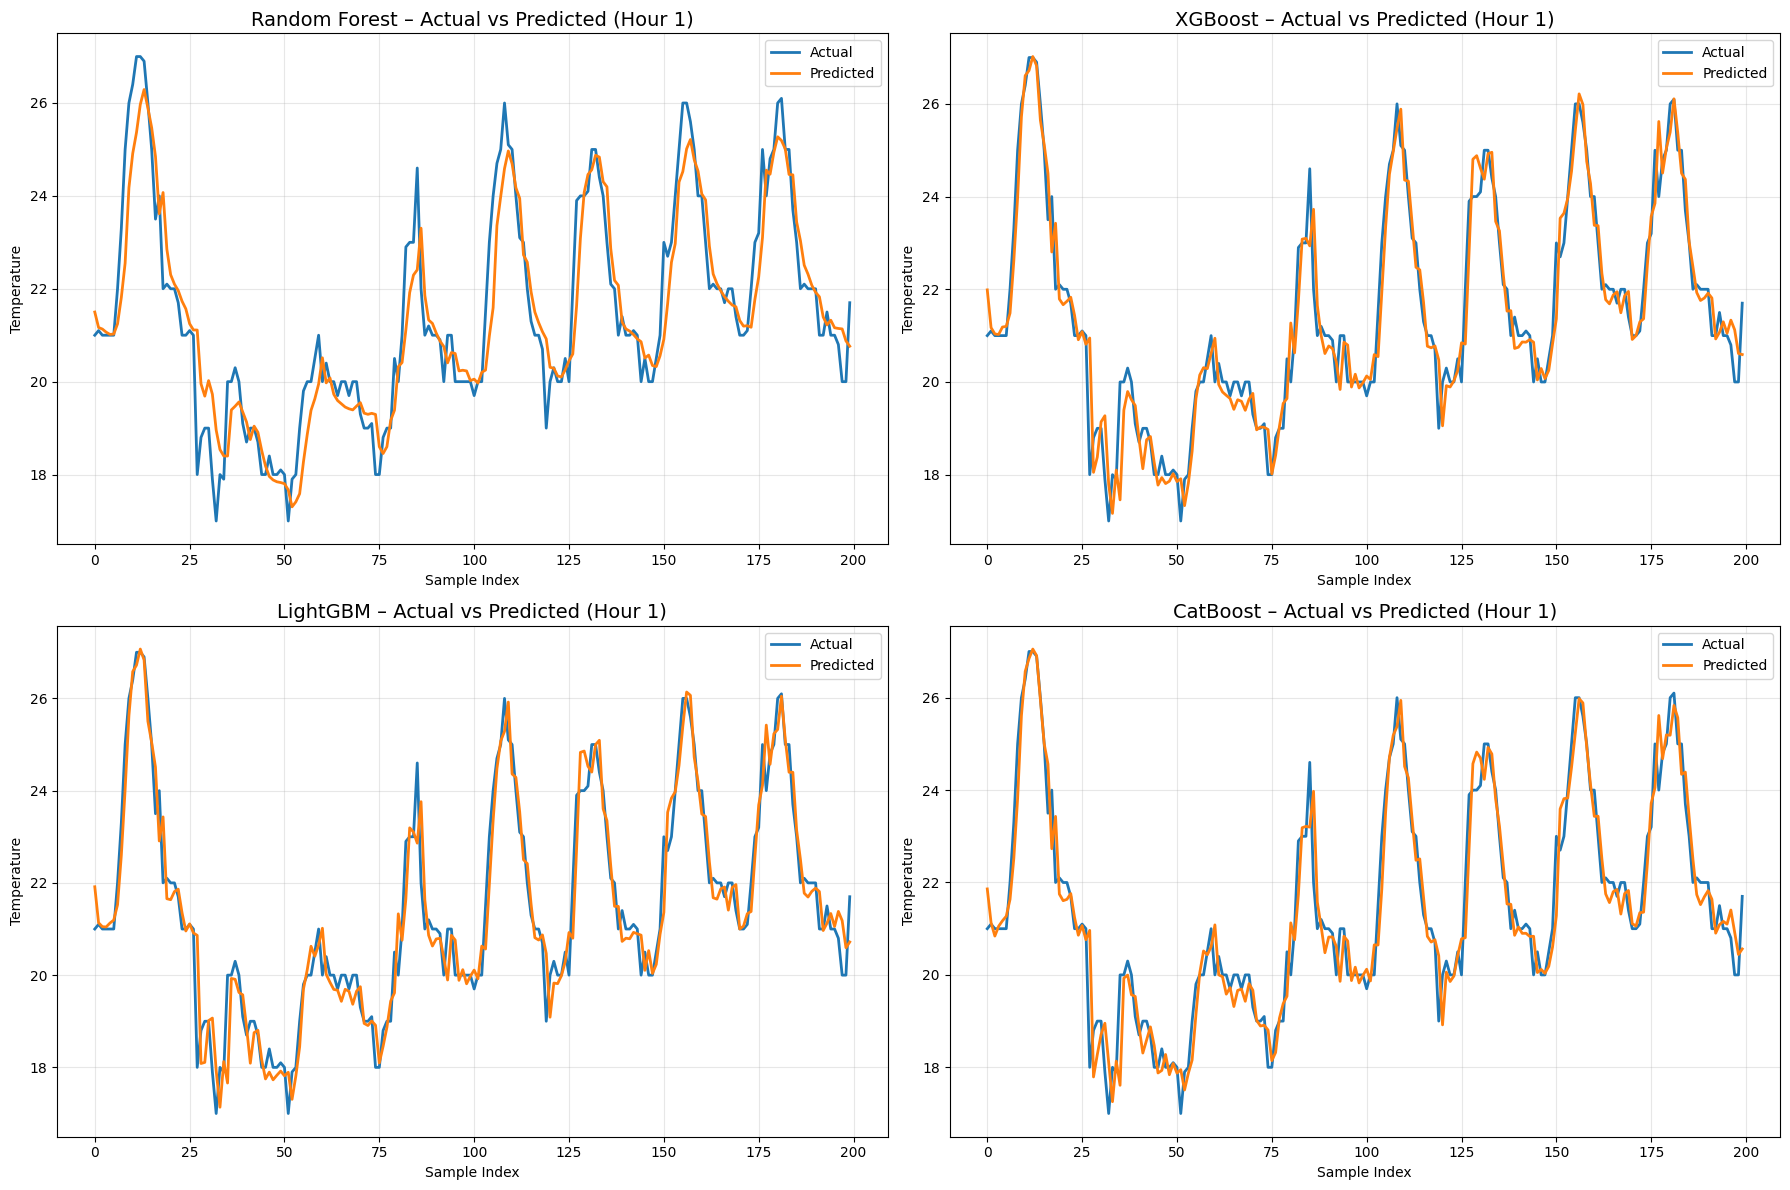

In [25]:
# ==========================================
# 📊 VISUALIZE 4 MODELS - DAY 1 PREDICTION
# ==========================================
import matplotlib.pyplot as plt

models_to_plot = ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]
hour = 1
sample_range = (0, 200) 

plt.figure(figsize=(18, 12))

for idx, model_name in enumerate(models_to_plot, 1):
    target_col = f"y_temp_h_{hour}"
    results = all_model_results[model_name][target_col]

    y_test_true = y_test_h[target_col].values[sample_range[0]:sample_range[1]]
    y_test_pred = results['test_pred'][sample_range[0]:sample_range[1]]

    plt.subplot(2, 2, idx)
    plt.plot(y_test_true, label='Actual', linewidth=2)
    plt.plot(y_test_pred, label='Predicted', linewidth=2)
    plt.title(f"{model_name} – Actual vs Predicted (Hour {hour})", fontsize=14)
    plt.xlabel("Sample Index")
    plt.ylabel("Temperature")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


## **SECTION 5:** ⏱️ PREDICT

Generate future-ready features and run 3-step temperature forecasts using the best trained models.

**Feature Generator:**
- Rebuilds the full training feature set for future timestamps
- Includes: difference features, wind vectors, pressure change, solar–cloud interaction
- Cyclical time encoding (month/day/hour)
- Rolling window stats (3h, 6h, 12h, 24h)
- Outputs only X_latest, with no targets and no row dropping

**Direct Forecasting Engine:**
- Produces Hour +1, +2, +3 predictions
- Supports all selected models
- Handles scaling, feature alignment, and iterative prediction
- Returns a unified table of multi-step forecasts across models

In [26]:
def create_hourly_features_for_forecast(df):
    """
    Create features exactly like create_features_and_split,
    but NOT create y, NOT dropna, used to get X_latest for future forecast.
    """
    df = df.copy()
    
    # ===== Basic differences & heatwave =====
    if 'temp' in df.columns and 'feelslike' in df.columns and 'dew' in df.columns:
        df['temp_dew_diff'] = df['temp'] - df['dew']
        df['feelslike_diff'] = df['feelslike'] - df['temp']
    
    # ===== Wind components =====
    if 'windspeed' in df.columns and 'winddir' in df.columns:
        df['wind_U'] = df['windspeed'] * np.sin(2*np.pi*df['winddir']/360)
        df['wind_V'] = df['windspeed'] * np.cos(2*np.pi*df['winddir']/360)
    
    # ===== Pressure change =====
    if 'sealevelpressure' in df.columns:
        df['pressure_hourly_change'] = df['sealevelpressure'].diff(1)
    
    # ===== Solar-cloud interaction =====
    if 'solarradiation' in df.columns and 'cloudcover' in df.columns:
        df['solar_cloud_interaction'] = df['solarradiation'] * (1 - df['cloudcover']/100)
    if 'solarradiation' in df.columns and 'cloudcover' in df.columns:
        df['solar_cloud_interaction'] = df['solarradiation'] * (1 - df['cloudcover']/100)
    
    # ===== Cyclical time features =====
    if 'datetime' in df.columns:
        df['month_sin'] = np.sin(2*np.pi*df['datetime'].dt.month/12)
        df['month_cos'] = np.cos(2*np.pi*df['datetime'].dt.month/12)
        df['day_sin'] = np.sin(2*np.pi*df['datetime'].dt.day_of_year/365.25)
        df['day_cos'] = np.cos(2*np.pi*df['datetime'].dt.day_of_year/365.25)
        df['hour_sin'] = np.sin(2*np.pi*df['datetime'].dt.hour/24)
        df['hour_cos'] = np.cos(2*np.pi*df['datetime'].dt.hour/24)
    
    # ===== Rolling features =====
    roll_cols = ['temp','feelslike','dew','humidity','precip','precipprob','windgust','windspeed',
                 'sealevelpressure','cloudcover','solarradiation','solarenergy','solar_cloud_interaction',
                 'wind_U','wind_V']
    windows = [3, 6, 12, 24]
    roll_features = []
    for col in roll_cols:
        if col not in df.columns: continue
        col_upper = col.upper()
        for w in windows:
            roll_features.append(df[col].shift(1).rolling(window=w, min_periods=1).mean().rename(f"{w}H_AVG_{col_upper}"))
            roll_features.append(df[col].shift(1).rolling(window=w, min_periods=1).var().rename(f"{w}H_VAR_{col_upper}"))
    
    # ===== Direct features =====
    direct_cols = ['temp','feelslike','dew','humidity','precip','precipprob','windgust','windspeed',
                   'sealevelpressure','cloudcover','solarradiation','solarenergy','solar_cloud_interaction',
                   'wind_U','wind_V','hour_sin','hour_cos','month_sin','month_cos','day_sin','day_cos']
    direct_features = [df[c] for c in direct_cols if c in df.columns]
    
    # ===== Combine features =====
    features_df = pd.concat(roll_features + direct_features, axis=1)
    
    return features_df


In [27]:
def predict_next_3_hours_direct(
    full_data,
    models_to_predict,
    all_model_results,
    X_train_h,
    scaler_name=None,
    scaled_datasets=None,
    window_hours=200,
    save_dir="../data/processed"
):
    """
    All-in-one: predict 3 hours into the future for ALL direct models.

    full_data: Raw DataFrame (train+val+test or latest), with 'datetime'
    models_to_predict: model configuration dict (same as direct part)
    all_model_results: metrics dict to get MAE as confidence interval
    X_train_h: DataFrame features train (used to align columns)
    scaler_name: scaler name (key in scaled_datasets) if any
    scaled_datasets: dict {scaler_name: {'scaler': scaler_obj, ...}}
    window_hours: last number of hours used to create features (>= max rolling window)
    save_dir: CSV save directory
    """
    print(f"\n{'='*100}")
    print("🔮 FUTURE PREDICTION (DIRECT MODELS) - NEXT 3 HOURS")
    print(f"{'='*100}\n")
    
    full_data = full_data.sort_values("datetime").reset_index(drop=True)
    
    # Take the last window to create features (ensure enough for rolling 84 days)
    last_window = full_data.tail(window_hours).copy()
    
    # Create full features for this window
    features_df = create_hourly_features_for_forecast(last_window)
    
    # Take the last row as input
    X_latest = features_df.iloc[[-1]].copy()
    
    # Align columns with X_train
    X_latest = X_latest.reindex(columns=X_train_h.columns, fill_value=0)
    
    # Create scaled version if best scaler is available
    if scaler_name is not None and scaled_datasets is not None:
        scaler = scaled_datasets[scaler_name]['scaler']
        X_latest_scaled = scaler.transform(X_latest)
        X_latest_scaled_df = pd.DataFrame(
            X_latest_scaled,
            columns=X_train_h.columns,
            index=X_latest.index
        )
        print(f"✅ Using scaler '{scaler_name}' for scaled predictions")
    else:
        X_latest_scaled_df = None
        print("ℹ️ No scaler provided – only original features will be used")
    
    last_hour = last_window["datetime"].iloc[-1]
    print(f"📅 Last known hour: {last_hour}")
    
    # Container for results
    all_model_predictions = {}
    
    # ==========================================
    # PREDICT FOR EACH MODEL
    # ==========================================
    
    for model_name, config in models_to_predict.items():
        # Choose data input for model
        if config.get('needs_scaling', False) and X_latest_scaled_df is not None:
            X_pred = X_latest_scaled_df
            # print("   ✓ Using SCALED features")
        else:
            X_pred = X_latest
            # print("   ✓ Using ORIGINAL features")
        
        predictions = []
        prediction_hours = []
        
        # print("\n   🔍 3-HOUR RAW PREDICTIONS\n")
        
        # Retrain model for each horizon on full data (train+val+test)
        for i, target_col in enumerate(['y_temp_h_1', 'y_temp_h_2', 'y_temp_h_3'], 1):
            # Initialize correct model type
            if model_name == 'Random Forest':
                model = RandomForestRegressor(
                    n_estimators=150, max_depth=5,
                    min_samples_leaf=10, min_samples_split=20,
                    max_features='sqrt', random_state=42, n_jobs=-1
                )
            elif model_name == 'Extra Trees':
                model = ExtraTreesRegressor(
                    n_estimators=150, max_depth=8, min_samples_split=5,
                    min_samples_leaf=2, max_features='sqrt',
                    random_state=42, n_jobs=-1
                )
            elif model_name == 'XGBoost':
                model = XGBRegressor(
                    n_estimators=100, max_depth=5, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, n_jobs=-1, verbosity=0
                )
            elif model_name == 'LightGBM':
                model = LGBMRegressor(
                    n_estimators=100, max_depth=5, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, n_jobs=-1, verbose=-1
                )
            elif model_name == 'CatBoost':
                model = CatBoostRegressor(
                    depth=6,
                    learning_rate=0.1,
                    n_estimators=300,
                    loss_function='RMSE',
                    random_seed=42,
                    verbose=False
                )
            elif model_name == 'Ridge':
                model = Ridge(alpha=1.0, random_state=42)
            elif model_name == 'Bayesian Ridge':
                model = BayesianRidge(compute_score=True)
            else:
                print(f"⚠️ Unknown model: {model_name}, skipping...")
                predictions = [np.nan]*5
                break
            
            # Prepare full X / y for training
            if config.get('needs_scaling', False) and X_latest_scaled_df is not None:
                X_full = pd.concat([X_train_scaled_df, X_val_scaled_df, X_test_scaled_df])
            else:
                X_full = pd.concat([X_train_h, X_val_h, X_test_h])
            
            y_full = pd.concat([y_train_h, y_val_h, y_test_h])
            
            model.fit(X_full, y_full[target_col])
            
            # Predict
            pred = model.predict(X_pred)[0]
            predictions.append(pred)
            
            pred_hour = last_hour + timedelta(hours=i)
            prediction_hours.append(pred_hour)
        
        # Build results DataFrame
        results_df = pd.DataFrame({
            'Hour_num': range(1, 4),
            'Date': prediction_hours,
            'Predicted_Temp': predictions
        })
        
        # Confidence interval based on measured test MAE
        avg_mae = np.mean([
            all_model_results[model_name][target_col]['mae_test']
            for target_col in ['y_temp_h_1', 'y_temp_h_2', 'y_temp_h_3']
        ])
        
        results_df['Lower_Bound'] = results_df['Predicted_Temp'] - avg_mae
        results_df['Upper_Bound'] = results_df['Predicted_Temp'] + avg_mae
        results_df['Model'] = model_name
        results_df['Uncertainty'] = avg_mae

        results_df['Day'] = results_df['Date'].dt.date
        results_df['Hour_str'] = results_df['Date'].dt.strftime('%H:%M')
        
        all_model_predictions[model_name] = results_df
        
        # Display table
        display_df = results_df.copy()
        display_df['Hour'] = display_df['Date'].dt.strftime('%Y-%m-%d %H:%M:%S')
        display_df['Predicted_Temp'] = display_df['Predicted_Temp'].round(2)
        display_df['Lower_Bound'] = display_df['Lower_Bound'].round(2)
        display_df['Upper_Bound'] = display_df['Upper_Bound'].round(2)
    
    # Combine all models
    combined_predictions = pd.concat(all_model_predictions.values(), ignore_index=True)
    # -------------------------------------------------------------
    # 🌟 BLOCK 1: PRINT SUMMARY TABLE OF ALL MODELS 🌟
    # -------------------------------------------------------------
    print(f"\n{'='*100}")
    print("📈 SUMMARY OF 3-HOUR PREDICTIONS (ALL MODELS)")
    print(f"{'='*100}\n")

    display_df_combined = combined_predictions.copy()

    # Formatting
    display_df_combined['Hour'] = display_df_combined['Date'].dt.strftime('%Y-%m-%d %H:%M:%S')
    display_df_combined['Predicted_Temp'] = display_df_combined['Predicted_Temp'].round(2)
    display_df_combined['Lower_Bound'] = display_df_combined['Lower_Bound'].round(2)
    display_df_combined['Upper_Bound'] = display_df_combined['Upper_Bound'].round(2)
    display_df_combined['Uncertainty'] = display_df_combined['Uncertainty'].round(2)

    # Display summary table
    cols_to_show = ['Model', 'Hour', 'Date', 'Predicted_Temp', 'Lower_Bound', 'Upper_Bound', 'Uncertainty']
    renamed_cols = {
        'Model': 'Model',
        'Hour_str': 'Hour',
        'Date': 'Date',
        'Predicted_Temp': 'Temp(°C)',
        'Lower_Bound': 'Lower',
        'Upper_Bound': 'Upper',
        'Uncertainty': 'MAE (±)'
    }
    
    print(
        display_df_combined[cols_to_show]
        .rename(columns=renamed_cols)
        .to_string(index=False)
    )
    print("-" * 100)
    
    # -----------------------------------------------------------------
    # 🌟 BLOCK 2: CALCULATE AND PRINT AVERAGE RESULTS OF THE 4 BEST MODELS 🌟
    # -----------------------------------------------------------------
    
    # 1. Define the 4 best models
    BEST_MODELS = ['Random Forest', 'CatBoost', 'XGBoost', 'LightGBM']
    
    # 2. Filter data to include only these 4 models
    best_model_predictions = combined_predictions[
        combined_predictions['Model'].isin(BEST_MODELS)
    ].copy()
    
    # 3. Calculate average by Day and Hour_str
    avg_predictions = best_model_predictions.groupby(['Day', 'Hour_str']).agg(
        Predicted_Temp_Avg=('Predicted_Temp', 'mean'),
        Lower_Bound_Avg=('Lower_Bound', 'mean'),
        Upper_Bound_Avg=('Upper_Bound', 'mean'),
        Avg_Uncertainty=('Uncertainty', 'mean')
    ).reset_index()
    
    # 4. Format the average results table
    avg_predictions['Hour_str'] = pd.to_datetime(avg_predictions['Day'].astype(str) + ' ' + avg_predictions['Hour_str']).dt.strftime('%Y-%m-%d %H:%M:%S')
    avg_predictions['Predicted_Temp_Avg'] = avg_predictions['Predicted_Temp_Avg'].round(2)
    avg_predictions['Lower_Bound_Avg'] = avg_predictions['Lower_Bound_Avg'].round(2)
    avg_predictions['Upper_Bound_Avg'] = avg_predictions['Upper_Bound_Avg'].round(2)
    avg_predictions['Avg_Uncertainty'] = avg_predictions['Avg_Uncertainty'].round(2)

    # 5. Display average results table
    # 1) Filter necessary columns and pivot table
    pivot_df = combined_predictions[['Day', 'Hour_str', 'Model', 'Predicted_Temp']].pivot(
        index=['Day','Hour_str'],
        columns='Model',
        values='Predicted_Temp'
    ).reset_index()

    # 2) Define the 4 best models and calculate the average column
    BEST_MODELS = ['Random Forest', 'CatBoost', 'XGBoost', 'LightGBM']

    # Get the model columns that are available in the best models list
    valid_avg_cols = [col for col in BEST_MODELS if col in pivot_df.columns]

    # Calculate the average for the 4 best models and create a new column
    pivot_df['AVG (Best 4)'] = pivot_df[valid_avg_cols].mean(axis=1)

    # 3) Format the final results
    pivot_df['Hour_str'] = pd.to_datetime(pivot_df['Day'].astype(str) + ' ' + pivot_df['Hour_str']).dt.strftime('%Y-%m-%d %H:%M:%S')
    # Round all temperature columns (from the 3rd column onwards)
    # Get the names of columns that are predicted temperatures
    temp_cols = [col for col in pivot_df.columns if col not in ['Day', 'Hour_str']]
    pivot_df[temp_cols] = pivot_df[temp_cols].round(2)
    
    # Reorder columns so that the average column is right after Date
    cols_order = ['Day', 'Hour_str', 'AVG (Best 4)'] + sorted(valid_avg_cols) + [
        col for col in pivot_df.columns if col not in ['Day', 'Hour_str', 'AVG (Best 4)'] + valid_avg_cols
    ]

    final_display_df = pivot_df[cols_order]

    # 4) Print the pivoted results table
    print(f"\n{'='*120}")
    print("📊 SUMMARY TABLE OF TEMPERATURE PREDICTIONS (HOUR vs MODEL) (°C)")
    print(f"{'='*120}\n")
    print(final_display_df.to_string(index=False))
    print(f"\n{'='*120}")
    
    return all_model_predictions, combined_predictions


In [28]:
models_to_predict = {
    'Random Forest': {'needs_scaling': False},
    'Extra Trees': {'needs_scaling': False},
    'XGBoost': {'needs_scaling': False},
    'LightGBM': {'needs_scaling': False},
    'CatBoost': {'needs_scaling': False},
    'Ridge': {'needs_scaling': True},
    'Bayesian Ridge': {'needs_scaling': True}
}


In [29]:
full_data = pd.concat([train_data_h, val_data_h, test_data_h], ignore_index=True)

all_model_predictions, combined_predictions = predict_next_3_hours_direct(
    full_data=full_data,
    models_to_predict=models_to_predict,
    all_model_results=all_model_results,
    X_train_h=X_train_h,
    scaler_name=scaler_name,       
    scaled_datasets=scaled_datasets,          
    window_hours=200,
    save_dir="../data/processed"
)


🔮 FUTURE PREDICTION (DIRECT MODELS) - NEXT 3 HOURS

✅ Using scaler 'MinMax_[0,1]_SAFE' for scaled predictions
📅 Last known hour: 2025-10-01 23:00:00

📈 SUMMARY OF 3-HOUR PREDICTIONS (ALL MODELS)

         Model                Hour                Date  Temp(°C)  Lower  Upper  MAE (±)
 Random Forest 2025-10-02 00:00:00 2025-10-02 00:00:00     26.66  25.60  27.72     1.06
 Random Forest 2025-10-02 01:00:00 2025-10-02 01:00:00     26.60  25.54  27.65     1.06
 Random Forest 2025-10-02 02:00:00 2025-10-02 02:00:00     26.49  25.44  27.55     1.06
   Extra Trees 2025-10-02 00:00:00 2025-10-02 00:00:00     26.57  25.43  27.71     1.14
   Extra Trees 2025-10-02 01:00:00 2025-10-02 01:00:00     26.57  25.43  27.71     1.14
   Extra Trees 2025-10-02 02:00:00 2025-10-02 02:00:00     26.58  25.44  27.72     1.14
       XGBoost 2025-10-02 00:00:00 2025-10-02 00:00:00     26.63  25.97  27.30     0.67
       XGBoost 2025-10-02 01:00:00 2025-10-02 01:00:00     26.29  25.62  26.95     0.67
       XGBo